# Assignment6 - Reinforcement Learning
**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


## Exercise 1 - Human reinforcemnet learning

In [1]:
import numpy as np

class Blackjack():
    """Simple blackjack environment adapted from OpenAI Gym:
        https://github.com/openai/gym/blob/master/gym/envs/toy_text/blackjack.py
    
    Blackjack is a card game where the goal is to obtain cards that sum to as
    near as possible to 21 without going over.  They're playing against a fixed
    dealer.
    
    Face cards (Jack, Queen, King) have point value 10.
    Aces can either count as 11 or 1, and it's called 'usable' at 11.
    This game is placed with a deck sampled with replacement.
    
    The game starts with each (player and dealer) having one face up and one
    face down card.
    
    The player can request additional cards (hit = 1) until they decide to stop
    (stay = 0) or exceed 21 (bust).
    
    After the player stays, the dealer reveals their facedown card, and draws
    until their sum is 17 or greater.  If the dealer goes bust the player wins.
    If neither player nor dealer busts, the outcome (win, lose, draw) is
    decided by whose sum is closer to 21.  The reward for winning is +1,
    drawing is 0, and losing is -1.
    
    The observation is a 3-tuple of: the players current sum,
    the dealer's one showing card (1-10 where 1 is ace),
    and whether or not the player holds a usable ace (0 or 1).
    
    This environment corresponds to the version of the blackjack problem
    described in Example 5.1 in Reinforcement Learning: An Introduction
    by Sutton and Barto (1998).
    
    http://incompleteideas.net/sutton/book/the-book.html
    
    Usage: 
        Initialize the class:
            game = Blackjack()
        
        Deal the cards:
            game.deal()
            
             (14, 3, False)
             
            This is the agent's observation of the state of the game:
            The first value is the sum of cards in your hand (14 in this case)
            The second is the visible card in the dealer's hand (3 in this case)
            The Boolean is a flag (False in this case) to indicate whether or 
                not you have a usable Ace
            (Note: if you have a usable ace, the sum will treat the ace as a 
                value of '11' - this is the case if this Boolean flag is "true")
            
        Take an action: Hit (1) or stay (0)
        
            Take a hit: game.step(1)
            To Stay:    game.step(0)
            
        The output summarizes the game status:
            
            ((15, 3, False), 0, False)
            
            The first tuple (15, 3, False), is the agent's observation of the
            state of the game as described above.
            The second value (0) indicates the rewards
            The third value (False) indicates whether the game is finished
    """
    
    def __init__(self):
        # 1 = Ace, 2-10 = Number cards, Jack/Queen/King = 10
        self.deck   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.dealer = []
        self.player = []
        self.deal()

    def step(self, action):
        if action == 1:  # hit: add a card to players hand and return
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                done = True
                reward = -1
            else:
                done = False
                reward = 0
        else:  # stay: play out the dealers hand, and score
            done = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
        return self._get_obs(), reward, done

    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], self.usable_ace(self.player))

    def deal(self):
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_obs()
    
    #------------------------------------------
    # Other helper functions
    #------------------------------------------
    def cmp(self, a, b):
        return float(a > b) - float(a < b)
    
    def draw_card(self):
        return int(np.random.choice(self.deck))
    
    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]
    
    def usable_ace(self,hand):  # Does this hand have a usable ace?
        return 1 in hand and sum(hand) + 10 <= 21
    
    def sum_hand(self,hand):  # Return current hand total
        if self.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)
    
    def is_bust(self,hand):  # Is this hand a bust?
        return self.sum_hand(hand) > 21
    
    def score(self,hand):  # What is the score of this hand (0 if bust)
        return 0 if self.is_bust(hand) else self.sum_hand(hand)

In [4]:
import numpy as np

# Initialize the class:
game = Blackjack()

# Deal the cards:
s0 = game.deal()
print(s0)

# Take an action: Hit = 1 or stay = 0. Here's a hit:
s1 = game.step(1)
print(s1)

# If you wanted to stay:
# game.step(2)

# When it's gameover, just redeal:
# game.deal()

(15, 7, False)
((20, 7, False), 0, False)


In [8]:
game = Blackjack()
rewards = []

for _ in range(20):
    s = game.deal()
    done = False
    while not done:
        action = np.random.choice([0, 1])
        s, reward, done = game.step(action)
    rewards.append(reward)

print(f"My rewards for each episode played were: {rewards}")
print(f"My average reward was {np.mean(rewards):.1f} after playing {len(rewards)} hands.")

My rewards for each episode played were: [-1, -1.0, -1.0, -1, 0.0, 1.0, -1.0, -1.0, -1.0, 1.0, -1, -1.0, 1.0, -1, -1.0, -1.0, 1.0, 1.0, -1, -1]
My average reward was -0.5 after playing 20 hands.


## Exercise 2 - Perform Monte Carlo Policy Evaluation

In [9]:
def policy_evaluation(N_episodes):
    # Initialize variables
    avg_return = []    # Accumulator to store the average returns over all episodes
    episode_count = 0  # Number of episodes played (will increment as more episodes are played)
    N_player   = 32    # Number of possible states of the players hand
                       #  The max hand value is 21, but then if the player busts 
                       #  they could reach 32 (if they had 21 and took a hit)
    N_dealer   = 10    # Maximum number of states the dealer's hand could take on
                       #  1 through 10 (Ace could be 1 or 11, but would still be a singe card in hand)
    N_ace      = 2     # There are two states for the ace: (1) No usable ace, (2) Usable ace
    
    # Initialize the state value function (in this case, the value function is the 
    #   average return over episodes, so no need for an explicit returns array)
    v = np.zeros((N_player, N_dealer, N_ace)) 
    
    # Initialize a variable counting the number of visits to each state
    n_visits = np.zeros((N_player, N_dealer, N_ace))
    
    # Initialize the policy that stays only if the player has 20 or 21, otherwise hit
    pi = np.zeros((32, 10, 2), dtype=int)
    for s in range(32):
        for d in range(10):
            for a in range(2):
                pi[s, d, a] = 0 if (s+1 >= 20) else 1  # s+1 because index starts at 0
    
    # Load the game
    B = Blackjack()
    
    # HELPER FUNCTIONS
    # Convert the current state into a set of indices for the value function
    def state_to_index(s):
        ace = 0
        if s[2]:
            ace = 1
        index = [s[0]-1, s[1]-1, ace]
        return index
    
    # Choose an action based on the policy, pi, and the current state, s
    def choose_action(pi,s):
        #######################
        # FILL IN THIS FUNCTION
        #######################
        # Outputs a value of 0 or 1
        index = state_to_index(s)
        return pi[index[0], index[1], index[2]]

    # ----------------------------------------------------------------------
    # Run the policy evaluation   
    # ----------------------------------------------------------------------
    cumulative_reward = 0

    for episode in range(N_episodes):
        # Deal a hand
        s = B.deal()
        states_visited = []
        done = False

        # Play the hand following the policy
        while not done:
            states_visited.append(s)
            action = choose_action(pi, s)
            s, reward, done = B.step(action)

        # Update cumulative average reward
        cumulative_reward += reward
        avg_return.append(cumulative_reward / (episode + 1))

        # Update state value function (first-visit MC)
        visited_set = set()
        for state in states_visited:
            idx = tuple(state_to_index(state))
            if idx not in visited_set:
                visited_set.add(idx)
                n_visits[idx] += 1
            # Incremental mean update
            v[idx] += (reward - v[idx]) / n_visits[idx]

        episode_count += 1

        return (v, avg_return)


In [10]:
# ---------------------------------------------------------------------------
# Sample plotting function for the state value function
# ---------------------------------------------------------------------------        

import matplotlib.pyplot as plt
# Uncomment the line below on macs for clearer plots:
# %config InlineBackend.figure_format = 'retina' 

# Plot the resulting state value function (expected returns from each state)
def plot_value(v):
    plt.figure(figsize=(10,7))
    drange = [1,10] # Dealer range
    prange = [4,21] # Player range
    axes = []
    axes.append(plt.subplot(1,2,1))
    plt.title('No Usable Ace')
    plt.imshow(v[prange[0]-1:prange[1],:,0], 
               vmin=-1,vmax=1,
               origin='lower', 
               extent=(drange[0]-0.5,
                       drange[1]+0.5,
                       prange[0]-0.5,
                       prange[1]+0.5),
               cmap = 'RdBu')
    plt.xticks(np.arange(drange[0],drange[1]+1,1))
    plt.yticks(np.arange(prange[0],prange[1]+1,1))
    plt.ylabel('Player Total')
    plt.xlabel('Dealer')
    
    axes.append(plt.subplot(1,2,2))
    plt.title('Usable Ace')
    im = plt.imshow(v[prange[0]-1:prange[1],:,1], 
               vmin=-1,vmax=1,
               origin='lower', 
               extent=(drange[0]-0.5,
                       drange[1]+0.5,
                       prange[0]-0.5,
                       prange[1]+0.5),
               cmap = 'RdBu')
    plt.xticks(np.arange(drange[0],drange[1]+1,1))
    plt.yticks(np.arange(prange[0],prange[1]+1,1))
    plt.ylabel('Player Total')
    plt.xlabel('Dealer')
    cbar = plt.colorbar(im, ax=axes)
    cbar.set_label('Value (Expected Returns)')

<Figure size 432x288 with 0 Axes>

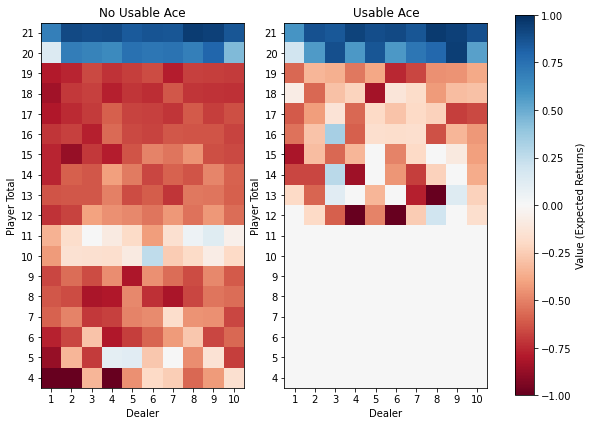

<Figure size 432x288 with 0 Axes>

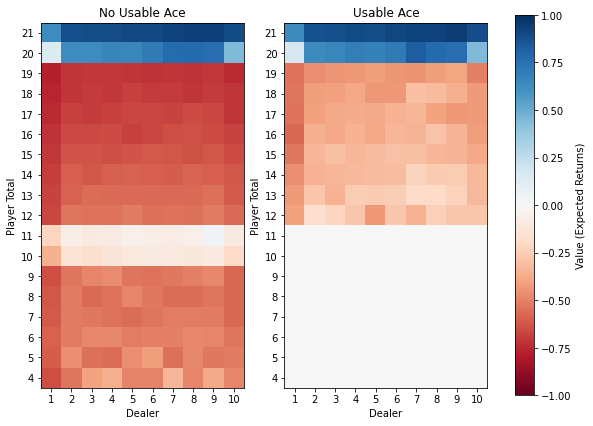

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def policy_evaluation(N_episodes):
    N_player = 32
    N_dealer = 10
    N_ace    = 2

    v        = np.zeros((N_player, N_dealer, N_ace))
    n_visits = np.zeros((N_player, N_dealer, N_ace))

    # Policy: hit unless player sum is 20 or 21
    pi = np.ones((N_player, N_dealer, N_ace), dtype=int)
    pi[19, :, :] = 0  # player sum = 20 -> stay
    pi[20, :, :] = 0  # player sum = 21 -> stay

    B = Blackjack()

    def state_to_index(s):
        ace = 1 if s[2] else 0
        return [s[0]-1, s[1]-1, ace]

    def choose_action(pi, s):
        idx = state_to_index(s)
        return pi[idx[0], idx[1], idx[2]]

    avg_return        = []
    cumulative_reward = 0

    for episode in range(N_episodes):
        s              = B.deal()
        done           = False
        states_visited = []

        while not done:
            states_visited.append(s)
            action         = choose_action(pi, s)
            s, reward, done = B.step(action)

        cumulative_reward += reward
        avg_return.append(cumulative_reward / (episode + 1))

        # First-visit MC update
        visited_set = set()
        for state in states_visited:
            idx = tuple(state_to_index(state))
            if idx not in visited_set:
                visited_set.add(idx)
                n_visits[idx] += 1
                v[idx] += (reward - v[idx]) / n_visits[idx]

    return v, avg_return


def plot_value(v):
    plt.figure(figsize=(10, 7))
    drange = [1, 10]
    prange = [4, 21]
    axes   = []

    axes.append(plt.subplot(1, 2, 1))
    plt.title('No Usable Ace')
    plt.imshow(v[prange[0]-1:prange[1], :, 0],
               vmin=-1, vmax=1,
               origin='lower',
               extent=(drange[0]-0.5, drange[1]+0.5,
                       prange[0]-0.5, prange[1]+0.5),
               cmap='RdBu')
    plt.xticks(np.arange(drange[0], drange[1]+1, 1))
    plt.yticks(np.arange(prange[0], prange[1]+1, 1))
    plt.ylabel('Player Total')
    plt.xlabel('Dealer')

    axes.append(plt.subplot(1, 2, 2))
    plt.title('Usable Ace')
    im = plt.imshow(v[prange[0]-1:prange[1], :, 1],
                    vmin=-1, vmax=1,
                    origin='lower',
                    extent=(drange[0]-0.5, drange[1]+0.5,
                            prange[0]-0.5, prange[1]+0.5),
                    cmap='RdBu')
    plt.xticks(np.arange(drange[0], drange[1]+1, 1))
    plt.yticks(np.arange(prange[0], prange[1]+1, 1))
    plt.ylabel('Player Total')
    plt.xlabel('Dealer')
    cbar = plt.colorbar(im, ax=axes)
    cbar.set_label('Value (Expected Returns)')


# Run policy evaluation
v_10k,  avg_10k  = policy_evaluation(10_000)
v_500k, avg_500k = policy_evaluation(500_000)

# 2.1 Plots 1 & 2: after 10,000 episodes
plt.suptitle('After 10,000 Episodes')
plot_value(v_10k)
plt.show()

# 2.1 Plots 3 & 4: after 500,000 episodes
plt.suptitle('After 500,000 Episodes')
plot_value(v_500k)
plt.show()


The value function plots show the expected returns from each state under the naive policy (hit unless player sum is 20 or 21). After 10,000 episodes, the estimates are noisy, especially for states with a usable ace, due to limited sampling. After 500,000 episodes, the estimates become much smoother and more stable. In both cases, states where the player holds 20 or 21 show the highest values (blue), as the policy stays in those states and wins more often. Most other states show negative expected returns (red), reflecting that aggressively hitting tends to result in busting frequently.

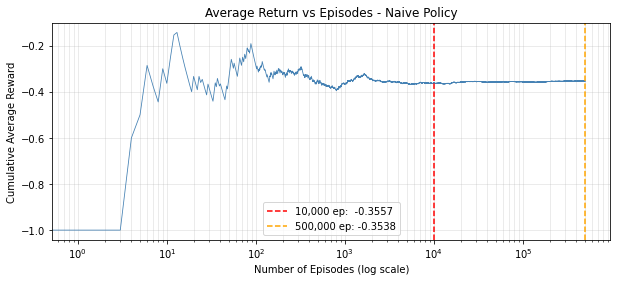

Average return at 10,000 episodes:  -0.3557
Average return at 500,000 episodes: -0.3538


In [14]:
# 2.2 Cumulative average reward vs episodes (log scale)
plt.figure(figsize=(10, 4))
plt.plot(avg_500k, color='steelblue', linewidth=0.8)
plt.xscale('log')
plt.xlabel('Number of Episodes (log scale)')
plt.ylabel('Cumulative Average Reward')
plt.title('Average Return vs Episodes - Naive Policy')
plt.axvline(x=10_000,  color='red',    linestyle='--',
            label=f'10,000 ep:  {avg_10k[-1]:.4f}')
plt.axvline(x=500_000, color='orange', linestyle='--',
            label=f'500,000 ep: {avg_500k[-1]:.4f}')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

print(f"Average return at 10,000 episodes:  {avg_10k[-1]:.4f}")
print(f"Average return at 500,000 episodes: {avg_500k[-1]:.4f}")

The cumulative average reward plot shows the average return over episodes on a log-scaled x-axis. The policy converges to a steady average reward around -0.35, indicating that this naive strategy loses more often than it wins. This is expected, since always hitting until 20 or 21 leads to frequent busts.